<a href="https://colab.research.google.com/github/ASHIK-77/ML_Project/blob/main/BiasVarianceAnalyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Create DataFrame
data = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target price column
data["Price"] = housing.target

# Display first 5 rows
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Features
X = data[housing.feature_names]

# Target
y = data["Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (16512, 8)
Testing data : (4128, 8)


In [ ]:
# Different tree depths
depths = [1, 2, 3, 5, 10, 15, 20]

train_mse = []
test_mse = []

train_r2 = []
test_r2 = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    # Calculate MSE
    training_error = mean_squared_error(
        y_train,
        train_prediction
    )

    testing_error = mean_squared_error(
        y_test,
        test_prediction
    )

    train_mse.append(training_error)
    test_mse.append(testing_error)

    # Calculate R²
    training_r2 = r2_score(
        y_train,
        train_prediction
    )

    testing_r2 = r2_score(
        y_test,
        test_prediction
    )

    train_r2.append(training_r2)
    test_r2.append(testing_r2)

In [ ]:
# Create results table
results = pd.DataFrame({
    "Depth": depths,
    "Training MSE": train_mse,
    "Testing MSE": test_mse,
    "Training R2": train_r2,
    "Testing R2": test_r2
})

print("FINAL RESULTS")
print("==========================")

results

FINAL RESULTS


,Depth,Training MSE,Testing MSE,Training R2,Testing R2
0,1,0.913024,0.944135,0.316997,0.279511
1,2,0.732495,0.754264,0.452045,0.424406
2,3,0.617728,0.642411,0.537898,0.509763
3,5,0.484343,0.524515,0.637679,0.599732
4,10,0.220866,0.415468,0.834778,0.682948
5,15,0.052594,0.463873,0.960656,0.646009
6,20,0.005727,0.489099,0.995716,0.626758


In [ ]:
for i in range(len(depths)):

    print("\n-----------------------------")
    print("Decision Tree Depth:", depths[i])
    print("Training MSE:", round(train_mse[i], 4))
    print("Testing MSE :", round(test_mse[i], 4))
    print("Training R2 :", round(train_r2[i], 4))
    print("Testing R2  :", round(test_r2[i], 4))


-----------------------------
Decision Tree Depth: 1
Training MSE: 0.913
Testing MSE : 0.9441
Training R2 : 0.317
Testing R2  : 0.2795

-----------------------------
Decision Tree Depth: 2
Training MSE: 0.7325
Testing MSE : 0.7543
Training R2 : 0.452
Testing R2  : 0.4244

-----------------------------
Decision Tree Depth: 3
Training MSE: 0.6177
Testing MSE : 0.6424
Training R2 : 0.5379
Testing R2  : 0.5098

-----------------------------
Decision Tree Depth: 5
Training MSE: 0.4843
Testing MSE : 0.5245
Training R2 : 0.6377
Testing R2  : 0.5997

-----------------------------
Decision Tree Depth: 10
Training MSE: 0.2209
Testing MSE : 0.4155
Training R2 : 0.8348
Testing R2  : 0.6829

-----------------------------
Decision Tree Depth: 15
Training MSE: 0.0526
Testing MSE : 0.4639
Training R2 : 0.9607
Testing R2  : 0.646

-----------------------------
Decision Tree Depth: 20
Training MSE: 0.0057
Testing MSE : 0.4891
Training R2 : 0.9957
Testing R2  : 0.6268


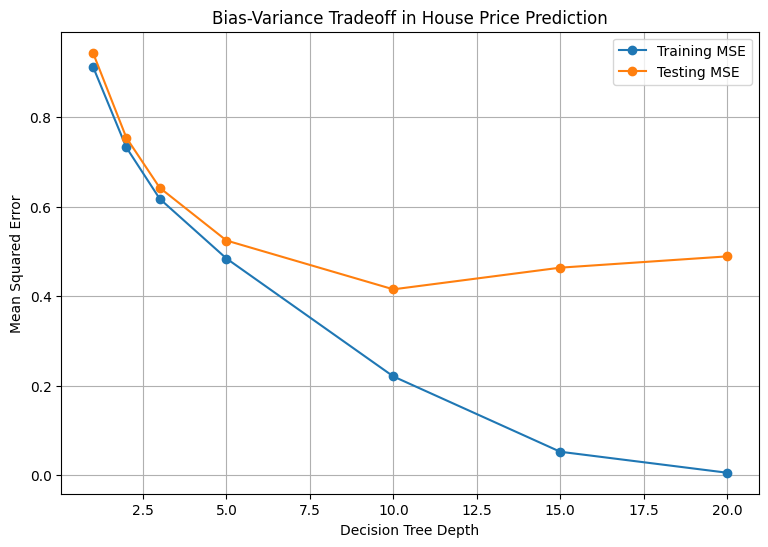

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    depths,
    train_mse,
    marker="o",
    label="Training MSE"
)

plt.plot(
    depths,
    test_mse,
    marker="o",
    label="Testing MSE"
)

plt.xlabel("Decision Tree Depth")
plt.ylabel("Mean Squared Error")

plt.title(
    "Bias-Variance Tradeoff in House Price Prediction"
)

plt.legend()
plt.grid(True)

plt.show()

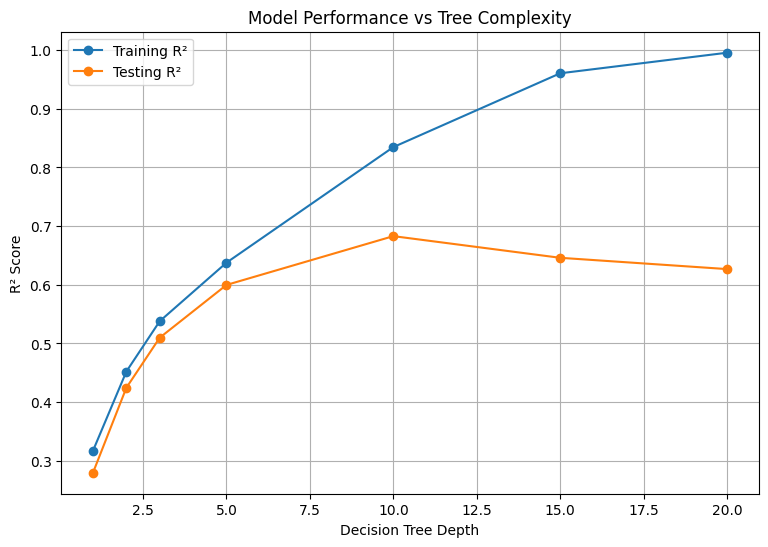

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    depths,
    train_r2,
    marker="o",
    label="Training R²"
)

plt.plot(
    depths,
    test_r2,
    marker="o",
    label="Testing R²"
)

plt.xlabel("Decision Tree Depth")
plt.ylabel("R² Score")

plt.title(
    "Model Performance vs Tree Complexity"
)

plt.legend()
plt.grid(True)

plt.show()